In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import networkx as nx
import pickle
import os
import glob

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Load the time reference file
times = pd.read_csv('times/times_1_hour.csv')

print("Shape:", times.shape)
print(times.head())

Shape: (6718, 2)
   id_time                       time
0        0  2023-10-09 00:00:00+00:00
1        1  2023-10-09 01:00:00+00:00
2        2  2023-10-09 02:00:00+00:00
3        3  2023-10-09 03:00:00+00:00
4        4  2023-10-09 04:00:00+00:00


In [3]:
# Path to the 1-hour aggregated data
folder = 'ip_addresses_sample/agg_1_hour/'

# Load the first 20 CSV files only
all_files = glob.glob(folder + '*.csv')[:20]

print(f"Found {len(all_files)} files")
print("First file:", all_files[0])

Found 20 files
First file: ip_addresses_sample/agg_1_hour\100610.csv


In [4]:
dfs = []

for f in all_files:
    df = pd.read_csv(f)
    df['ip_id'] = os.path.basename(f).replace('.csv', '')
    dfs.append(df)

# Combine everything
combined = pd.concat(dfs, ignore_index=True)

# Merge with timestamps
combined = combined.merge(times, on='id_time', how='left')

print("Total rows:", combined.shape[0])
print("Columns:", list(combined.columns))
print(combined.head())

Total rows: 71306
Columns: ['id_time', 'n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl', 'ip_id', 'time']
   id_time  n_flows  n_packets  n_bytes  sum_n_dest_asn  average_n_dest_asn  \
0        0       78        452    58128              60               10.00   
1        1       81        327    40388              64               10.67   
2        2       53        228    27508              49                8.17   
3        3       48        235    32750              38                6.33   
4        4       72        263    34248              42                7.00   

   std_n_dest_asn  sum_n_dest_ports  average_n_dest_ports  std_n_dest_ports  \
0            1.79                70                 11.67      

In [5]:
kpi_cols = [
    'n_flows', 'n_packets', 'n_bytes',
    'sum_n_dest_ip', 'average_n_dest_ip',
    'sum_n_dest_ports', 'average_n_dest_ports',
    'sum_n_dest_asn', 'average_n_dest_asn',
    'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes',
    'dir_ratio_packets', 'dir_ratio_bytes',
    'avg_duration', 'avg_ttl'
]

combined = combined.dropna(subset=kpi_cols)

print("Rows after cleaning:", combined.shape[0])
print(combined[kpi_cols].describe())

Rows after cleaning: 71306
             n_flows     n_packets       n_bytes  sum_n_dest_ip  \
count   71306.000000  7.130600e+04  7.130600e+04   71306.000000   
mean     2604.085982  3.430529e+05  3.386286e+08     990.575968   
std      9904.915441  1.279211e+06  1.252563e+09    2980.412519   
min         2.000000  2.000000e+00  7.200000e+01       2.000000   
25%        41.000000  1.580000e+02  1.453525e+04      35.000000   
50%       111.000000  8.890000e+02  1.709970e+05      83.000000   
75%      1236.000000  8.371750e+03  3.307938e+06     576.000000   
max    148102.000000  2.059247e+07  2.308840e+10   60390.000000   

       average_n_dest_ip  sum_n_dest_ports  average_n_dest_ports  \
count       71306.000000      71306.000000          71306.000000   
mean          165.540424        184.669761             31.090048   
std           496.842436       1002.412079            167.036524   
min             1.000000          2.000000              1.000000   
25%             6.500000     

In [6]:
pearson_corr = combined[kpi_cols].corr(method='pearson')
spearman_corr = combined[kpi_cols].corr(method='spearman')

print("Pearson correlation matrix:")
print(pearson_corr.round(2))

Pearson correlation matrix:
                       n_flows  n_packets  n_bytes  sum_n_dest_ip  \
n_flows                   1.00       0.96     0.94           0.96   
n_packets                 0.96       1.00     1.00           0.94   
n_bytes                   0.94       1.00     1.00           0.93   
sum_n_dest_ip             0.96       0.94     0.93           1.00   
average_n_dest_ip         0.96       0.94     0.93           1.00   
sum_n_dest_ports          0.50       0.44     0.43           0.46   
average_n_dest_ports      0.50       0.44     0.43           0.46   
sum_n_dest_asn            0.88       0.88     0.87           0.94   
average_n_dest_asn        0.88       0.88     0.87           0.94   
tcp_udp_ratio_packets     0.05       0.09     0.09           0.07   
tcp_udp_ratio_bytes       0.05       0.09     0.10           0.07   
dir_ratio_packets        -0.24      -0.29    -0.30          -0.29   
dir_ratio_bytes          -0.33      -0.37    -0.37          -0.40   
avg_du

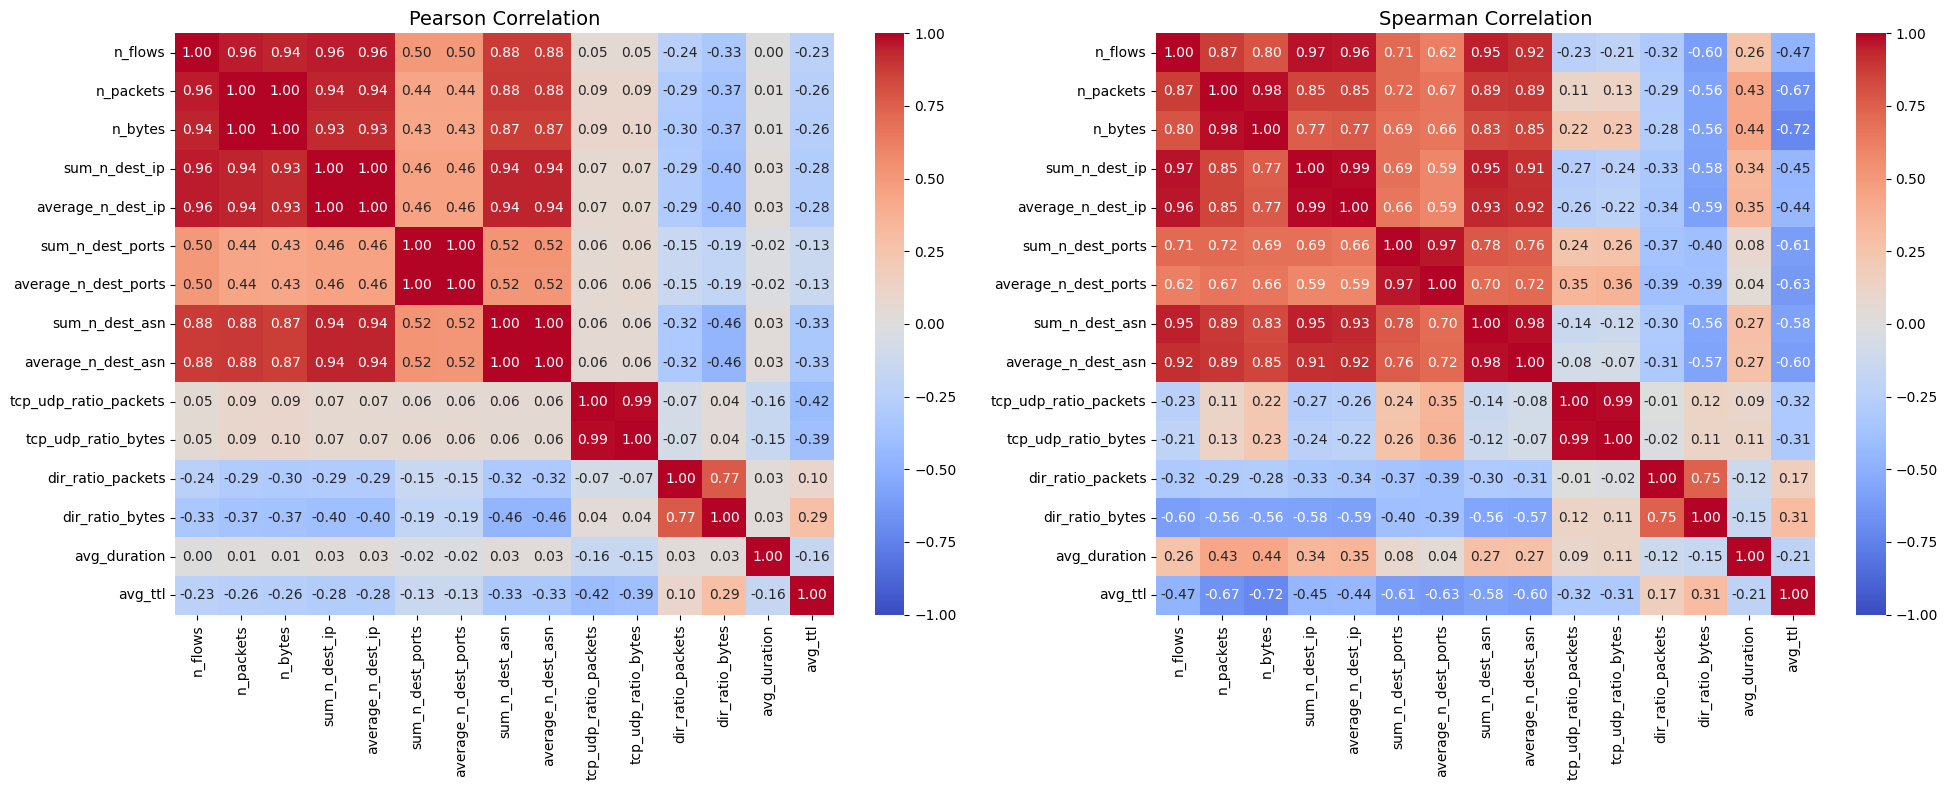

Heatmap saved to artifacts folder


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(pearson_corr, annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation', fontsize=14)

sns.heatmap(spearman_corr, annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Correlation', fontsize=14)

plt.tight_layout()
plt.savefig('artifacts/correlation_heatmap.png', dpi=150)
plt.show()

print("Heatmap saved to artifacts folder")

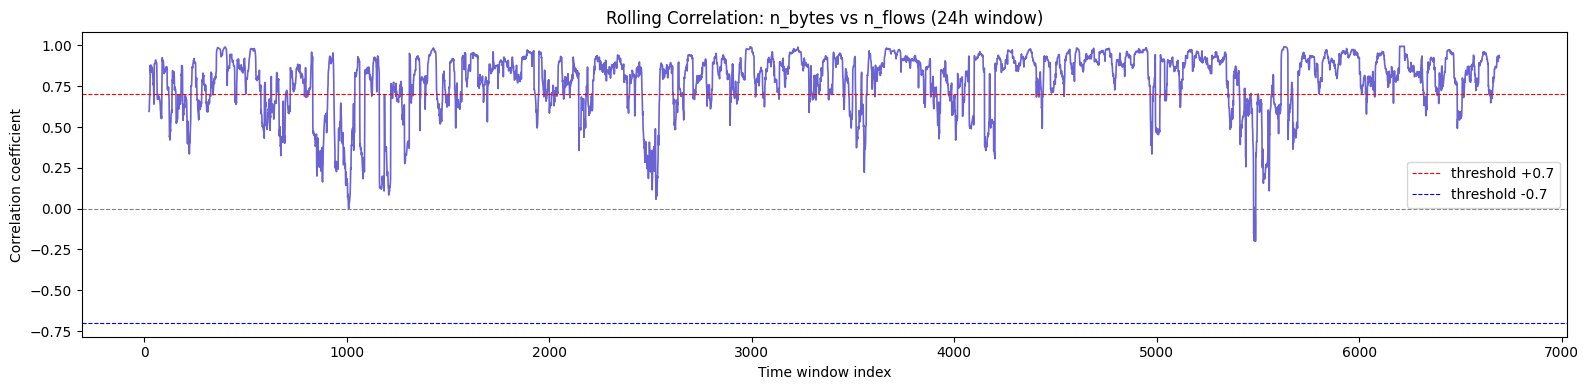

Rolling correlation saved


In [8]:
single_ip = pd.read_csv(all_files[0])
single_ip = single_ip.merge(times, on='id_time', how='left')
single_ip = single_ip.dropna(subset=kpi_cols)

window = 24
rolling = single_ip['n_bytes'].rolling(window).corr(single_ip['n_flows'])

plt.figure(figsize=(16, 4))
plt.plot(rolling.values, color='#6B63D4', linewidth=1.2)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0.7, color='red', linestyle='--', linewidth=0.8, label='threshold +0.7')
plt.axhline(-0.7, color='blue', linestyle='--', linewidth=0.8, label='threshold -0.7')
plt.title('Rolling Correlation: n_bytes vs n_flows (24h window)')
plt.xlabel('Time window index')
plt.ylabel('Correlation coefficient')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/rolling_correlation.png', dpi=150)
plt.show()

print("Rolling correlation saved")

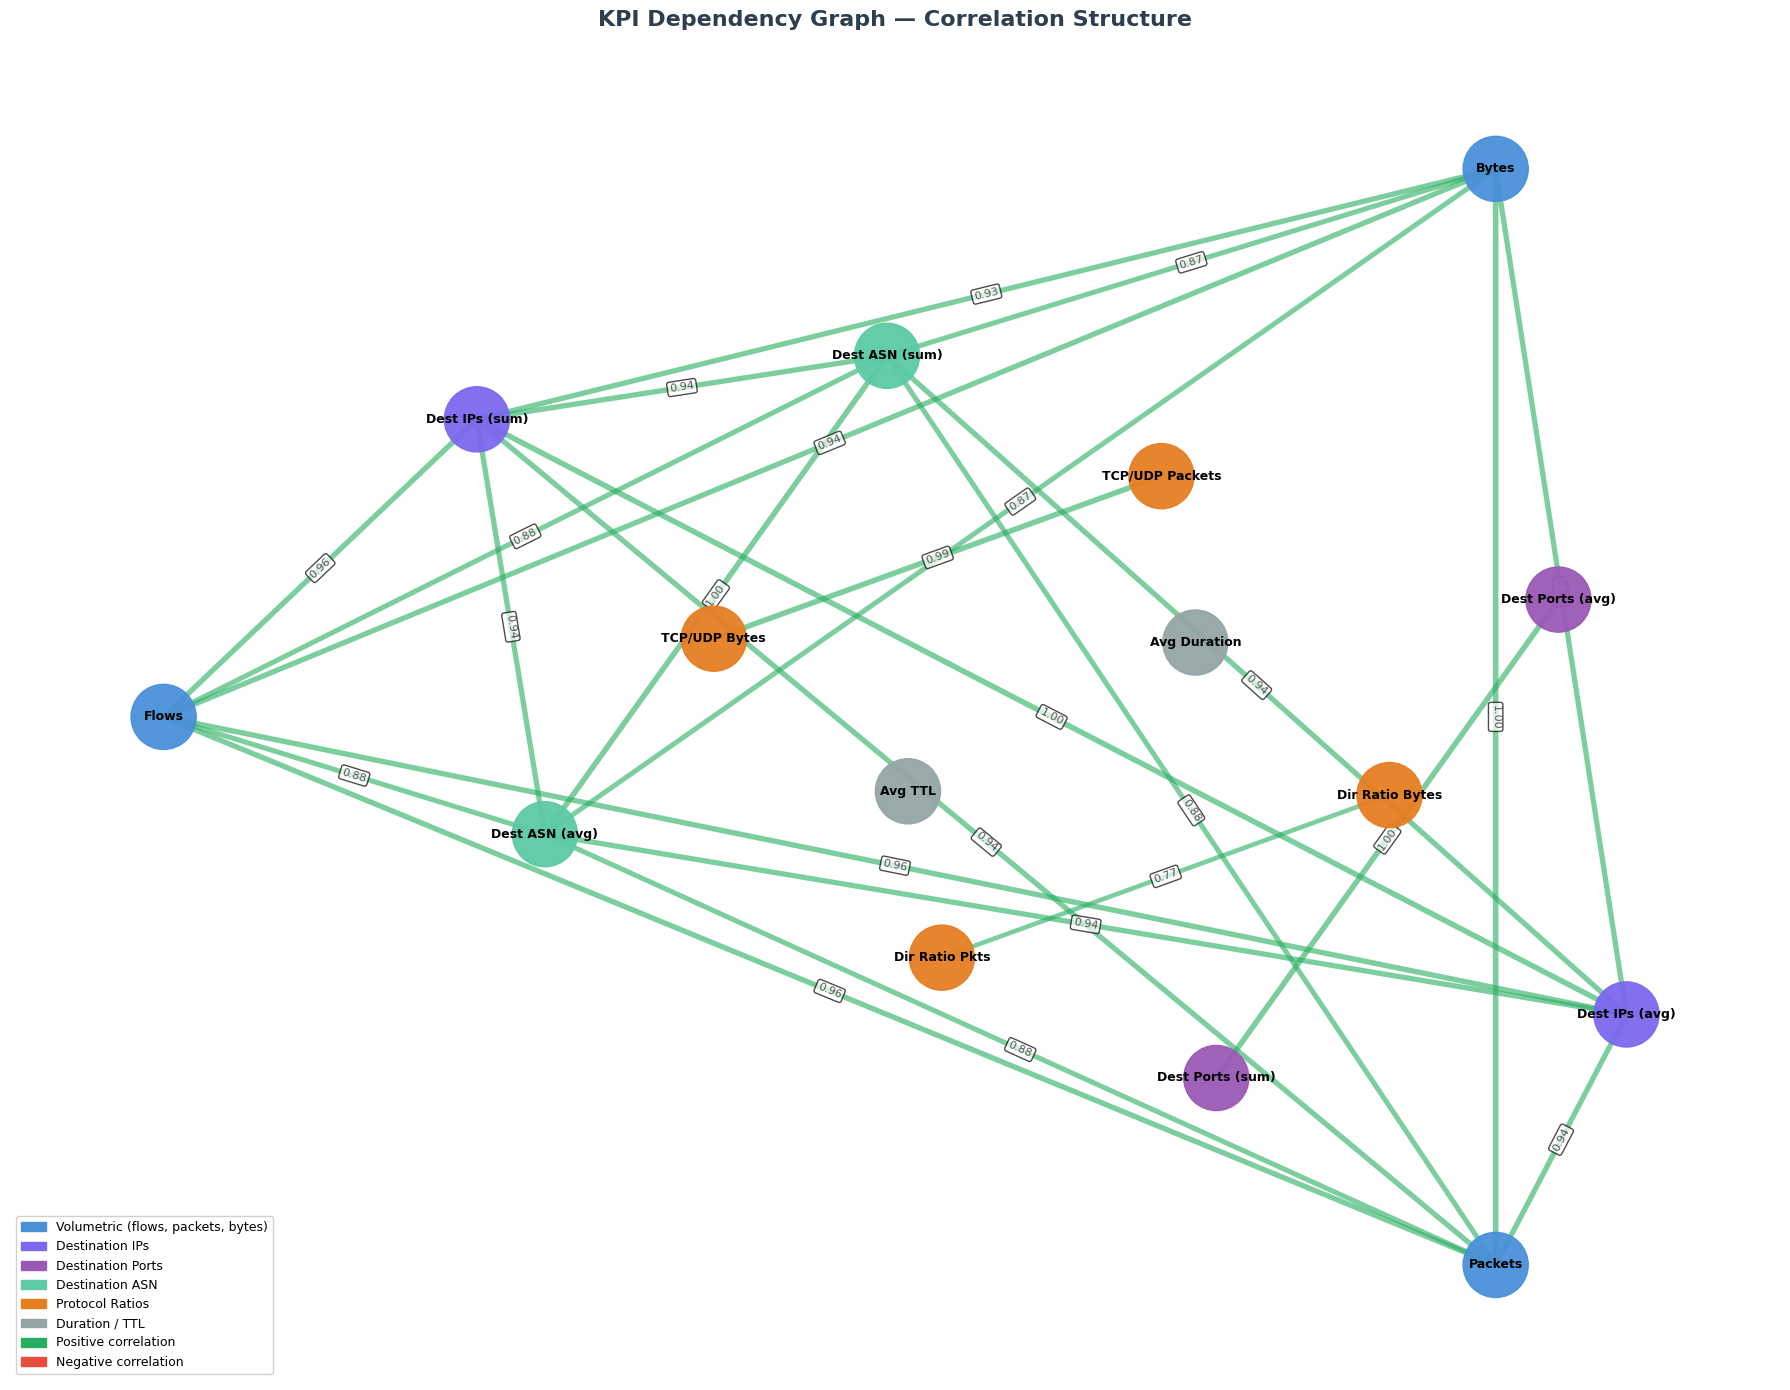

Clean dependency graph saved


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

# Shorter readable labels for each KPI
label_map = {
    'n_flows': 'Flows',
    'n_packets': 'Packets',
    'n_bytes': 'Bytes',
    'sum_n_dest_ip': 'Dest IPs (sum)',
    'average_n_dest_ip': 'Dest IPs (avg)',
    'sum_n_dest_ports': 'Dest Ports (sum)',
    'average_n_dest_ports': 'Dest Ports (avg)',
    'sum_n_dest_asn': 'Dest ASN (sum)',
    'average_n_dest_asn': 'Dest ASN (avg)',
    'tcp_udp_ratio_packets': 'TCP/UDP Packets',
    'tcp_udp_ratio_bytes': 'TCP/UDP Bytes',
    'dir_ratio_packets': 'Dir Ratio Pkts',
    'dir_ratio_bytes': 'Dir Ratio Bytes',
    'avg_duration': 'Avg Duration',
    'avg_ttl': 'Avg TTL'
}

# Build graph with threshold
threshold = 0.7
G = nx.Graph()

# Add all nodes first
for col in pearson_corr.columns:
    G.add_node(col)

# Add edges for strong correlations only
for i in range(len(pearson_corr.columns)):
    for j in range(i+1, len(pearson_corr.columns)):
        val = pearson_corr.iloc[i, j]
        if abs(val) > threshold:
            G.add_edge(
                pearson_corr.columns[i],
                pearson_corr.columns[j],
                weight=round(abs(val), 2),
                sign=1 if val > 0 else -1
            )

# Use shell layout for clean separation
# Group nodes by category for the shells
volumetric = ['n_flows', 'n_packets', 'n_bytes']
dest_ip    = ['sum_n_dest_ip', 'average_n_dest_ip']
dest_port  = ['sum_n_dest_ports', 'average_n_dest_ports']
dest_asn   = ['sum_n_dest_asn', 'average_n_dest_asn']
ratios     = ['tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes',
              'dir_ratio_packets', 'dir_ratio_bytes']
misc       = ['avg_duration', 'avg_ttl']

shells = [misc, ratios, dest_asn + dest_port, dest_ip, volumetric]
pos = nx.shell_layout(G, nlist=shells)

# --- Color nodes by category ---
color_map = {}
for n in G.nodes():
    if n in volumetric:
        color_map[n] = '#4A90D9'      # blue
    elif n in dest_ip:
        color_map[n] = '#7B68EE'      # purple
    elif n in dest_port:
        color_map[n] = '#9B59B6'      # violet
    elif n in dest_asn:
        color_map[n] = '#5DCAA5'      # teal
    elif n in ratios:
        color_map[n] = '#E67E22'      # orange
    else:
        color_map[n] = '#95A5A6'      # gray

node_colors = [color_map[n] for n in G.nodes()]

# --- Edge colors: green = positive, red = negative ---
edge_colors = []
edge_widths = []
for u, v, d in G.edges(data=True):
    edge_colors.append('#27AE60' if d['sign'] == 1 else '#E74C3C')
    edge_widths.append(1 + d['weight'] * 3)

# --- Draw ---
fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Draw edges
nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color=edge_colors,
    width=edge_widths,
    alpha=0.6)

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=node_colors,
    node_size=2200,
    alpha=0.95)

# Draw labels with short names, black text
short_labels = {n: label_map.get(n, n) for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=short_labels, ax=ax,
    font_size=9,
    font_color='black',
    font_weight='bold')

# Draw edge weight labels
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
    font_size=8,
    font_color='#555555',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# --- Legend ---
legend_elements = [
    mpatches.Patch(color='#4A90D9', label='Volumetric (flows, packets, bytes)'),
    mpatches.Patch(color='#7B68EE', label='Destination IPs'),
    mpatches.Patch(color='#9B59B6', label='Destination Ports'),
    mpatches.Patch(color='#5DCAA5', label='Destination ASN'),
    mpatches.Patch(color='#E67E22', label='Protocol Ratios'),
    mpatches.Patch(color='#95A5A6', label='Duration / TTL'),
    mpatches.Patch(color='#27AE60', label='Positive correlation'),
    mpatches.Patch(color='#E74C3C', label='Negative correlation'),
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=9, framealpha=0.9,
          facecolor='white', edgecolor='#cccccc')

ax.set_title('KPI Dependency Graph — Correlation Structure',
             fontsize=16, fontweight='bold', pad=20, color='#2C3E50')

plt.axis('off')
plt.tight_layout()
plt.savefig('artifacts/dependency_graph.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Clean dependency graph saved")

In [10]:
with open('artifacts/correlation_matrix.pkl', 'wb') as f:
    pickle.dump({
        'pearson': pearson_corr,
        'spearman': spearman_corr
    }, f)

with open('artifacts/dependency_graph.pkl', 'wb') as f:
    pickle.dump(G, f)

print("All artifacts saved successfully")
print("Files in artifacts folder:")
for file in os.listdir('artifacts'):
    print(" -", file)

All artifacts saved successfully
Files in artifacts folder:
 - baseline_stats.pkl
 - cluster_model.pkl
 - cluster_plot.png
 - correlation_artifacts.pkl
 - correlation_heatmap.png
 - correlation_matrix.pkl
 - correlation_model.pkl
 - correlation_scaler.pkl
 - dependency_graph.pkl
 - dependency_graph.png
 - elbow_plot.png
 - log_cols.pkl
 - model_comparison.png
 - model_features.pkl
 - raw_baseline.pkl
 - residual_analysis.png
 - risk_config.pkl
 - rolling_correlation.png
 - shap_bar.png
 - shap_columns.pkl
 - shap_explainer.pkl
 - shap_summary.png


In [11]:
with open('artifacts/correlation_matrix.pkl', 'rb') as f:
    loaded = pickle.load(f)

print("Pearson matrix loaded:")
print(loaded['pearson'].round(2))

with open('artifacts/dependency_graph.pkl', 'rb') as f:
    loaded_graph = pickle.load(f)

print("\nGraph nodes:", list(loaded_graph.nodes()))
print("Graph edges:", list(loaded_graph.edges()))

Pearson matrix loaded:
                       n_flows  n_packets  n_bytes  sum_n_dest_ip  \
n_flows                   1.00       0.96     0.94           0.96   
n_packets                 0.96       1.00     1.00           0.94   
n_bytes                   0.94       1.00     1.00           0.93   
sum_n_dest_ip             0.96       0.94     0.93           1.00   
average_n_dest_ip         0.96       0.94     0.93           1.00   
sum_n_dest_ports          0.50       0.44     0.43           0.46   
average_n_dest_ports      0.50       0.44     0.43           0.46   
sum_n_dest_asn            0.88       0.88     0.87           0.94   
average_n_dest_asn        0.88       0.88     0.87           0.94   
tcp_udp_ratio_packets     0.05       0.09     0.09           0.07   
tcp_udp_ratio_bytes       0.05       0.09     0.10           0.07   
dir_ratio_packets        -0.24      -0.29    -0.30          -0.29   
dir_ratio_bytes          -0.33      -0.37    -0.37          -0.40   
avg_duratio

In [12]:
print("KEY FINDINGS — Root Cause Indicators")
print("=" * 50)

for i in range(len(pearson_corr.columns)):
    for j in range(i+1, len(pearson_corr.columns)):
        val = pearson_corr.iloc[i, j]
        if abs(val) > 0.7:
            direction = "also increases" if val > 0 else "decreases"
            strength = "strongly" if abs(val) > 0.9 else "moderately"
            print(f"→ When {pearson_corr.columns[i]} increases, "
                  f"{pearson_corr.columns[j]} {direction} "
                  f"({strength}, r={val:.2f})")

KEY FINDINGS — Root Cause Indicators
→ When n_flows increases, n_packets also increases (strongly, r=0.96)
→ When n_flows increases, n_bytes also increases (strongly, r=0.94)
→ When n_flows increases, sum_n_dest_ip also increases (strongly, r=0.96)
→ When n_flows increases, average_n_dest_ip also increases (strongly, r=0.96)
→ When n_flows increases, sum_n_dest_asn also increases (moderately, r=0.88)
→ When n_flows increases, average_n_dest_asn also increases (moderately, r=0.88)
→ When n_packets increases, n_bytes also increases (strongly, r=1.00)
→ When n_packets increases, sum_n_dest_ip also increases (strongly, r=0.94)
→ When n_packets increases, average_n_dest_ip also increases (strongly, r=0.94)
→ When n_packets increases, sum_n_dest_asn also increases (moderately, r=0.88)
→ When n_packets increases, average_n_dest_asn also increases (moderately, r=0.88)
→ When n_bytes increases, sum_n_dest_ip also increases (strongly, r=0.93)
→ When n_bytes increases, average_n_dest_ip also incr

In [13]:
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

print("SHAP ready")

c:\Users\LENOVO-PCµ\Desktop\dashboard\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP ready


In [14]:
# Use n_bytes as target — we want to explain what drives byte volume
X = combined[kpi_cols].drop(columns=['n_bytes'])
y = combined['n_bytes']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train a small Random Forest
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_scaled, y)

print("Model trained")

Model trained


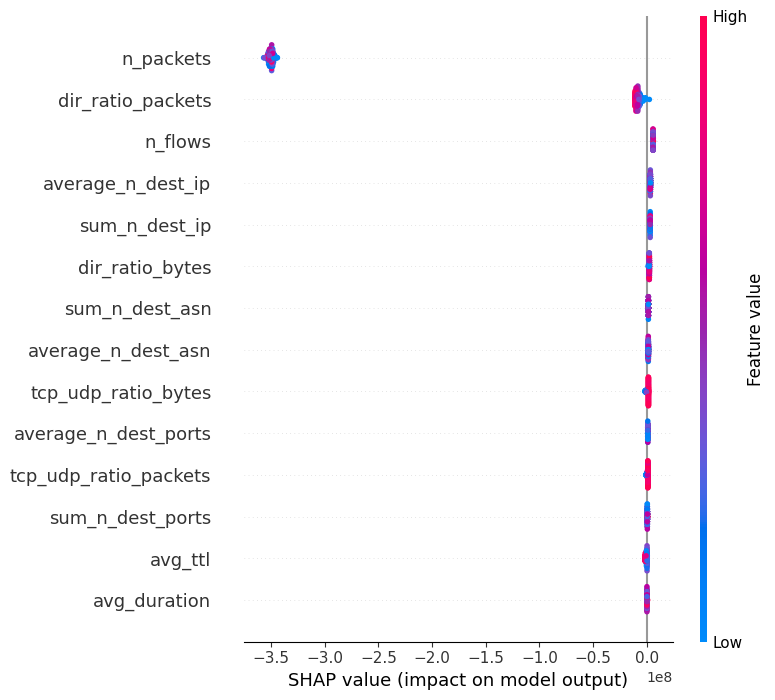

SHAP summary saved


In [15]:
# Use a sample of 200 rows for speed
sample = X_scaled[:200]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X.iloc[:200],
                  feature_names=X.columns.tolist(),
                  show=False)
plt.tight_layout()
plt.savefig('artifacts/shap_summary.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

print("SHAP summary saved")

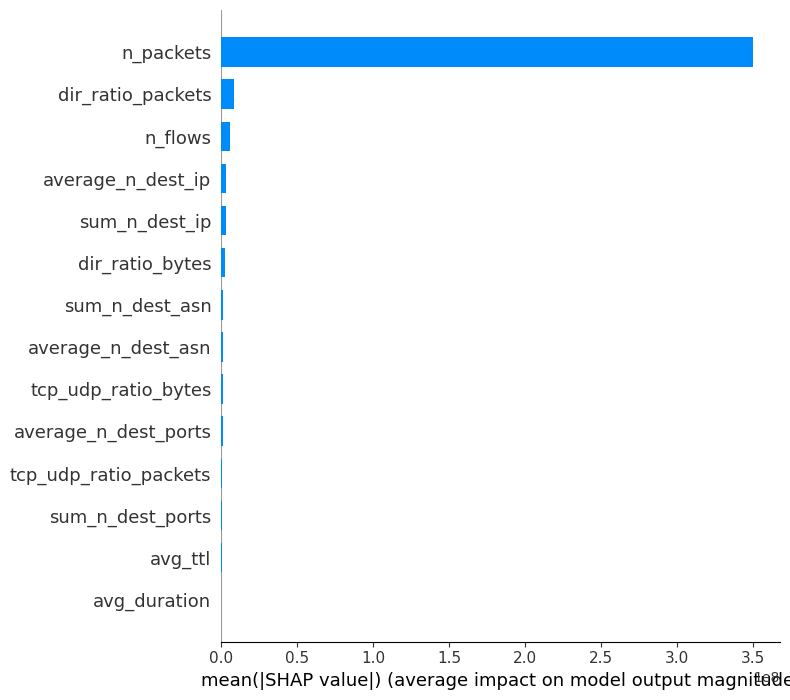

SHAP bar plot saved


In [16]:
plt.figure()
shap.summary_plot(shap_values, X.iloc[:200],
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.tight_layout()
plt.savefig('artifacts/shap_bar.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

print("SHAP bar plot saved")

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

print("Clustering ready")

Clustering ready


In [18]:
# Work with combined dataframe
# Create time-based features from the time column
combined['time'] = pd.to_datetime(combined['time'])
combined['hour'] = combined['time'].dt.hour
combined['dayofweek'] = combined['time'].dt.dayofweek
combined['is_weekend'] = (combined['dayofweek'] >= 5).astype(int)

print("Temporal features created")
print(combined[['time', 'hour', 'dayofweek', 'is_weekend']].head())

Temporal features created
                       time  hour  dayofweek  is_weekend
0 2023-10-09 00:00:00+00:00     0          0           0
1 2023-10-09 01:00:00+00:00     1          0           0
2 2023-10-09 02:00:00+00:00     2          0           0
3 2023-10-09 03:00:00+00:00     3          0           0
4 2023-10-09 04:00:00+00:00     4          0           0


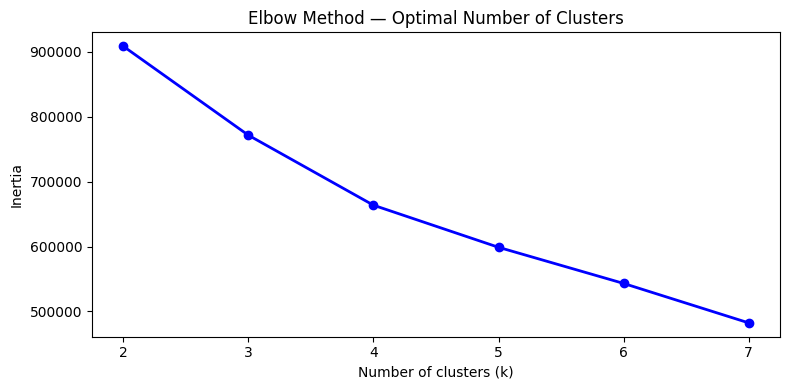

Elbow plot saved


In [19]:
# Features for clustering: KPIs + temporal
cluster_features = kpi_cols + ['hour', 'dayofweek', 'is_weekend']

cluster_data = combined[cluster_features].dropna()

# Scale
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

# Find optimal clusters using elbow method
inertias = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.tight_layout()
plt.savefig('artifacts/elbow_plot.png', dpi=150, facecolor='white')
plt.show()

print("Elbow plot saved")

C:\Users\LENOVO-PCµ\AppData\Local\Temp\ipykernel_13620\770520697.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\LENOVO-PCµ\AppData\Local\Temp\ipykernel_13620\770520697.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('artifacts/cluster_plot.png',
c:\Users\LENOVO-PCµ\Desktop\dashboard\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


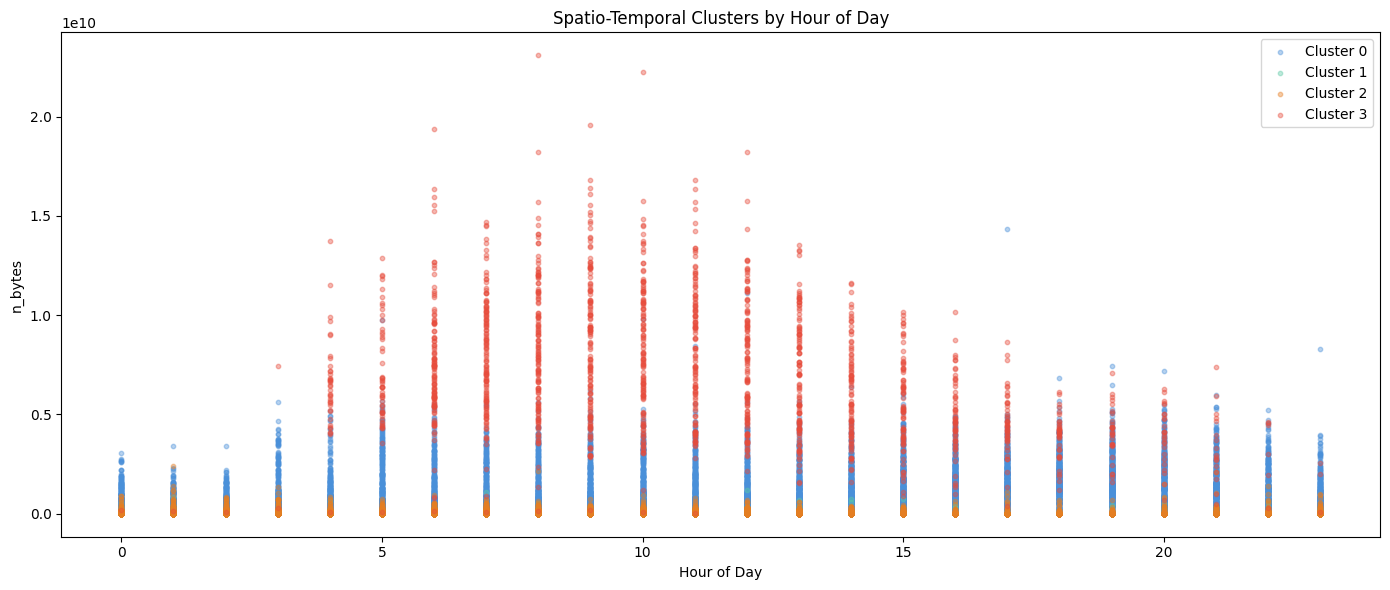

Cluster model saved


In [20]:
# Use k=4 (you can adjust after seeing the elbow plot)
k = 4
km_final = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_data = cluster_data.copy()
cluster_data['cluster'] = km_final.fit_predict(cluster_scaled)

# Plot clusters by hour of day
plt.figure(figsize=(14, 6))
colors = ['#4A90D9', '#5DCAA5', '#E67E22', '#E74C3C']

for i in range(k):
    subset = cluster_data[cluster_data['cluster'] == i]
    plt.scatter(subset['hour'], subset['n_bytes'],
                alpha=0.4, s=10,
                color=colors[i],
                label=f'Cluster {i}')

plt.xlabel('Hour of Day')
plt.ylabel('n_bytes')
plt.title('Spatio-Temporal Clusters by Hour of Day')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/cluster_plot.png',
            dpi=150, facecolor='white')
plt.show()

# Save cluster model
with open('artifacts/cluster_model.pkl', 'wb') as f:
    pickle.dump({
        'model': km_final,
        'scaler': scaler_cluster,
        'features': cluster_features
    }, f)

print("Cluster model saved")

In [21]:
# Show what each cluster looks like on average
cluster_summary = cluster_data.groupby('cluster')[kpi_cols].mean().round(2)
print("Cluster profiles:")
print(cluster_summary)

# Label clusters by behavior
cluster_labels = {}
for i in range(k):
    avg_bytes = cluster_summary.loc[i, 'n_bytes']
    avg_flows = cluster_summary.loc[i, 'n_flows']
    avg_hour  = cluster_data[cluster_data['cluster']==i]['hour'].mean()

    if avg_bytes > cluster_summary['n_bytes'].median():
        label = "High Traffic"
    else:
        label = "Low Traffic"

    cluster_labels[i] = f"Cluster {i}: {label} (avg hour: {avg_hour:.0f}h)"

for k_id, label in cluster_labels.items():
    print(f"→ {label}")

Cluster profiles:
          n_flows   n_packets       n_bytes  sum_n_dest_ip  average_n_dest_ip  \
cluster                                                                         
0         6826.72  1197040.95  1.216384e+09        3102.06             517.09   
1          590.34     3345.48  1.835387e+06         258.41              43.34   
2          214.97    15595.23  1.311787e+07         120.47              20.76   
3        59957.26  7350827.18  7.078033e+09       17670.20            2946.16   

         sum_n_dest_ports  average_n_dest_ports  sum_n_dest_asn  \
cluster                                                           
0                  476.80                 79.50          625.81   
1                   24.68                  4.26           86.84   
2                   71.08                 12.40           48.23   
3                 3409.91                568.47         2647.03   

         average_n_dest_asn  tcp_udp_ratio_packets  tcp_udp_ratio_bytes  \
cluster          

In [22]:
import pickle
import os

# Load all your existing pkl files
def load(name):
    with open(f'artifacts/{name}', 'rb') as f:
        return pickle.load(f)

# Bundle everything into one dictionary
bundle = {
    'model':          load('correlation_model.pkl'),
    'scaler':         load('correlation_scaler.pkl'),
    'baseline_stats': load('baseline_stats.pkl'),
    'raw_baseline':   load('raw_baseline.pkl'),
    'cluster_model':  load('cluster_model.pkl'),
    'risk_config':    load('risk_config.pkl'),
    'shap_explainer': load('shap_explainer.pkl'),
    'shap_columns':   load('shap_columns.pkl'),
    'model_features': load('model_features.pkl'),
}

# Save as one single file
with open('artifacts/correlation_artifacts.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("Done — single file saved")
print(f"Size: {os.path.getsize('artifacts/correlation_artifacts.pkl') / 1024 / 1024:.1f} MB")

Done — single file saved
Size: 22.0 MB


In [23]:
bundle = {
    'model':          load('correlation_model.pkl'),
    'scaler':         load('correlation_scaler.pkl'),
    'baseline_stats': load('baseline_stats.pkl'),
    'raw_baseline':   load('raw_baseline.pkl'),
    'cluster_model':  load('cluster_model.pkl'),
    'risk_config':    load('risk_config.pkl'),
    'shap_explainer': load('shap_explainer.pkl'),
    'shap_columns':   load('shap_columns.pkl'),
    'model_features': load('model_features.pkl'),
    'pearson_corr':   load('correlation_matrix.pkl')['pearson'],
}

with open('artifacts/correlation_artifacts.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("Bundle saved with pearson_corr included")

Bundle saved with pearson_corr included
